In [1]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3

In [3]:
data = {
    'MCQ': {
        'intra_dataset': {  # ArabicMMLU
            'AceGPT-7B': {'Base': [37.51, 31.23, 31.41, 39.10, 36.52], 
                         'Chat': [47.10, 28.26, 31.83, 42.54, 40.72],
                         'Tuned': [56.24, 51.54, 43.63, 56.79, 54.60]},
            'LLaMA3.1-8B': {'Base': [48.74, 29.60, 31.74, 46.32, 43.34],
                            'Instruct': [54.64, 28.96, 32.92, 53.27, 50.34],
                            'Tuned': [57.25, 54.75, 51.13, 56.77, 56.98]}
        },
        'intra_task': {  # ArabicMMLU → Belebele
            'AceGPT-7B': {'Base': [35.67, 24.00, 32.78, 26.33, 22.78],
                         'Chat': [39.67, 27.22, 42.56, 39.89, 26.00],
                         'Tuned': [43.78, 30.00, 46.56, 44.78, 40.00]},
            'LLaMA3.1-8B': {'Base': [52.89, 26.22, 50.11, 49.11, 45.00],
                            'Instruct': [58.67, 22.56, 57.56, 53.56, 52.67],
                            'Tuned': [58.56, 35.44, 56.00, 56.56, 57.00]}
        }
    },
    'NLI': {
        'intra_dataset': {  # ArEntail
            'AceGPT-7B': {'Base': [51.5, 50.8, 50.0, 50.0, 51.9],
                         'Chat': [50.0, 52.7, 50.0, 50.0, 51.0],
                         'Tuned': [82.9, 77.1, 64.4, 74.9, 79.2]},
            'LLaMA3.1-8B': {'Base': [50.6, 50.2, 51.6, 50.0, 51.0],
                            'Instruct': [56.3, 73.4, 64.6, 50.6, 65.9],
                            'Tuned': [90.3, 91.1, 91.6, 91.9, 90.5]}
        },
        'intra_task': {  # ArEntail → ArabicTE
            'AceGPT-7B': {'Base': [44.08, 57.35, 49.53, 49.76, 52.13],
                         'Chat': [50.24, 59.24, 47.16, 52.13, 55.45],
                         'Tuned': [60.19, 52.13, 66.59, 52.13, 53.08]},
            'LLaMA3.1-8B': {'Base': [51.66, 53.79, 52.13, 52.13, 52.13],
                            'Instruct': [52.84, 53.32, 52.37, 56.40, 55.45],
                            'Tuned': [58.06, 52.13, 55.45, 54.03, 56.40]}
        }
    },
    'Dialect': {
        'intra_dataset': {  # AraBench
            'AceGPT-7B': {'Base': [21.86, 14.59, 13.08, 21.07, 13.08],
                         'Chat': [20.89, 14.79, 14.48, 15.87, 13.08],
                         'Tuned': [45.12, 45.82, 39.84, 51.46, 27.25]},
            'LLaMA3.1-8B': {'Base': [15.69, 20.12, 14.46, 14.31, 13.02],
                            'Instruct': [15.81, 25.36, 14.37, 14.24, 13.02],
                            'Tuned': [88.39, 89.05, 89.24, 89.19, 88.91]}
        },
        'intra_task': {  # AraBench → Arabic Dialects Dataset
            'AceGPT-7B': {'Base': [17.64, 16.13, 19.88, 16.87, 16.13],
                         'Chat': [17.72, 16.13, 16.41, 19.09, 16.13],
                         'Tuned': [52.62, 44.38, 26.03, 20.96, 43.21]},
            'LLaMA3.1-8B': {'Base': [23.06, 16.13, 18.07, 19.71, 16.13],
                            'Instruct': [44.87, 16.13, 23.54, 30.99, 16.13],
                            'Tuned': [37.98, 19.50, 28.50, 26.70, 23.24]}
        }
    },
    'Sarcasm': {
        'intra_dataset': {  # ArSarcasm-v2
            'AceGPT-7B': {'Base': [72.63, 72.63, 72.63, 72.17, 71.07],
                         'Chat': [72.63, 72.63, 72.63, 72.63, 72.63],
                         'Tuned': [77.50, 78.57, 78.03, 78.27, 77.77]},
            'LLaMA3.1-8B': {'Base': [72.63, 72.63, 72.63, 69.50, 72.50],
                            'Instruct': [72.63, 43.57, 72.63, 72.60, 72.63],
                            'Tuned': [79.07, 78.13, 78.27, 75.60, 78.70]}
        },
        'intra_task': {  # ArSarcasm → iSarcasmEval
            'AceGPT-7B': {'Base': [14.29, 29.14, 85.64, 85.71, 85.36],
                         'Chat': [14.29, 14.43, 85.71, 85.71, 19.29],
                         'Tuned': [16.00, 15.93, 85.50, 85.64, 86.86]},
            'LLaMA3.1-8B': {'Base': [14.29, 16.00, 85.43, 85.71, 85.71],
                            'Instruct': [28.79, 14.29, 85.71, 85.64, 85.71],
                            'Tuned': [14.29, 14.29, 85.71, 85.29, 85.79]}
        }
    },
    'Trans.': {
        'intra_dataset': {  # OPUS-100
            'AceGPT-7B': {'Base': [7.96, 6.88, 9.04, 2.05, 2.10],
                         'Chat': [8.87, 9.46, 9.78, 9.54, 7.63],
                         'Tuned': [16.56, 16.05, 16.19, 16.49, 16.03]},
            'LLaMA3.1-8B': {'Base': [8.74, 8.02, 8.13, 4.68, 3.42],
                            'Instruct': [8.11, 9.69, 8.98, 9.07, 3.20],
                            'Tuned': [14.26, 14.35, 13.81, 13.66, 14.05]}
        },
        'intra_task': {  # OPUS-100 → Tatoeba
            'AceGPT-7B': {'Base': [6.13, 16.15, 15.10, 13.18, 10.75],
                         'Chat': [9.68, 16.69, 16.71, 16.01, 16.41],
                         'Tuned': [14.97, 13.18, 10.48, 13.13, 13.03]},
            'LLaMA3.1-8B': {'Base': [0.17, 14.56, 14.18, 14.55, 10.77],
                            'Instruct': [1.20, 14.76, 13.90, 14.62, 15.07],
                            'Tuned': [7.60, 10.30, 10.67, 10.34, 10.56]}
        }
    },
    'Summarization': {
        'intra_dataset': {  # XLSUM
            'AceGPT-7B': {'Base': [0.74, 0.58, 0.47, 0.61, 3.58],
                         'Chat': [1.14, 0.65, 0.25, 0.64, 0.38],
                         'Tuned': [7.15, 7.19, 7.17, 7.19, 10.87]},
            'LLaMA3.1-8B': {'Base': [0.39, 0.32, 0.06, 0.36, 0.98],
                            'Instruct': [0.54, 0.40, 0.04, 0.35, 1.11],
                            'Tuned': [5.82, 5.76, 5.81, 5.78, 8.66]}
        },
        'intra_task': {  # XLSUM → AraSum
            'AceGPT-7B': {'Base': [0.61, 1.10, 2.96, 0.85, 0.67],
                         'Chat': [0.04, 0.07, 3.68, 0.57, 0.47],
                         'Tuned': [5.99, 6.04, 5.25, 5.24, 6.02]},
            'LLaMA3.1-8B': {'Base': [0.31, 0.32, 0.08, 0.83, 0.65],
                            'Instruct': [1.20, 0.92, 2.33, 1.10, 1.83],
                            'Tuned': [5.48, 6.34, 5.35, 4.95, 5.36]}
        }
    }
}

In [4]:
def create_scatter_plot(figsize=(16, 9)):
    """Create T0-style scatter plot comparing intra-dataset vs intra-task performance"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, sharey=False)
    
    # Define distinct colors for better visibility
    colors = {
        'AceGPT-7B': {'Base': "#FFD6DB", 'Chat': "#FF0000", 'Tuned': "#750000"},  # Red family
        'LLaMA3.1-8B': {'Base': "#DDF4FF", 'Instruct': "#0084FF", 'Tuned': "#00366B"}  # Blue family
    }
    
    # Define baseline markers for accuracy tasks
    # baseline_data = {
    #     'NLU': {'random': 20.0, 'first_choice': 30.9, 'intra_dataset': 'ArabicMMLU', 'intra_task': 'Belebele'},
    #     'NLI': {'random': 50.0, 'first_choice': 50.0, 'intra_dataset': 'ArEntail', 'intra_task': 'ArabicTE'},  # Binary task
    #     'Dialect': {'random': 16.6, 'first_choice': 14.5, 'intra_dataset': 'AraBench', 'intra_task': 'Arabic Dialects'},
    #     'Sarcasm': {'random': 50.0, 'first_choice': 50.0, 'intra_dataset': 'ArSarcasm', 'intra_task': 'iSarcasmEval'}  # Binary task
    # }
    
    # Map datasets to baseline values
    dataset_baselines = {
        'ArabicMMLU': {'random': 20.0, 'first_choice': 30.9},
        'Belebele': {'random': 25.0, 'first_choice': 22.9},
        'ArEntail': {'random': 50.0, 'first_choice': 50.0},
        'ArabicTE': {'random': 50.0, 'first_choice': 50.0},
        'AraBench': {'random': 16.6, 'first_choice': 14.5},
        'Arabic Dialects': {'random': 20.0, 'first_choice': 17.6},
        'ArSarcasm': {'random': 50.0, 'first_choice': None}, # prompts here are mixed, so there is no universal first_choice baseline
        'iSarcasmEval': {'random': 50.0, 'first_choice': None} # prompts here are mixed, so there is no universal first_choice baseline
    }
    
    tasks = list(data.keys())
    conditions = ['intra_dataset', 'intra_task']
    condition_titles = ['Intra-Dataset', 'Intra-Task']
    
    # Define task categories for BLEU vs Accuracy
    accuracy_tasks = ['MCQ', 'NLI', 'Dialect', 'Sarcasm']  # First 4 tasks
    bleu_tasks = ['Translation', 'Summarization']  # Last 2 tasks
    
    for cond_idx, (condition, ax, title) in enumerate(zip(conditions, [ax1, ax2], condition_titles)):
        
        # Calculate x positions for tasks
        x_positions = np.arange(len(tasks))
        
        # Add gray bars between task groups
        # Light gray bars between individual tasks
        for i in range(len(tasks) - 1):
            ax.axvline(x=i + 0.5, color='lightgray', linewidth=1, alpha=0.7)
        
        # Darker gray bar between accuracy and BLEU tasks (after 4th task)
        ax.axvline(x=3.5, color='gray', linewidth=3, alpha=0.8)
        
        # Add baseline markers for accuracy tasks only
        for task_idx, task in enumerate(accuracy_tasks):
            x_center = x_positions[task_idx]
            x_left = x_center - 0.4
            x_right = x_center + 0.4
            
            # Get the appropriate dataset for this condition
            if condition == 'intra_dataset':
                dataset_map = {'MCQ': 'ArabicMMLU', 'NLI': 'ArEntail', 'Dialect': 'AraBench', 'Sarcasm': 'ArSarcasm'}
            else:  # intra_task
                dataset_map = {'MCQ': 'Belebele', 'NLI': 'ArabicTE', 'Dialect': 'Arabic Dialects', 'Sarcasm': 'iSarcasmEval'}
            
            dataset_name = dataset_map[task]
            baselines = dataset_baselines[dataset_name]
            
            # Random baseline (dashed line)
            ax.hlines(baselines['random'], x_left, x_right, 
                     colors='green', linestyles='dashed', linewidth=2, alpha=0.8)
            
            # First choice bias (dotted line)
            if baselines['first_choice']:
                ax.hlines(baselines['first_choice'], x_left, x_right, 
                        colors='purple', linestyles='dotted', linewidth=2, alpha=0.8)
        
        # For each task
        for task_idx, task in enumerate(tasks):
            x_base = x_positions[task_idx]
            
            # For each model
            for model_idx, model in enumerate(['AceGPT-7B', 'LLaMA3.1-8B']):
                # Offset for model separation
                model_offset = -0.15 if model_idx == 0 else 0.15
                
                # For each variant
                for variant_key, values in data[task][condition][model].items():
                    # Calculate x position with small random jitter for visibility
                    x_pos = x_base + model_offset + np.random.normal(0, 0.03, len(values))
                    
                    # Plot points with larger size and better edge contrast
                    ax.scatter(x_pos, values, 
                             c=colors[model][variant_key], 
                             alpha=0.8, 
                             s=80,  # Increased from 60
                             edgecolors='black',  # Changed from white for better contrast
                             linewidth=0.8)  # Slightly thicker edge
        
        # Customize axes
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(tasks, rotation=0, ha='center', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_axisbelow(True)
        
        # Increase y-axis tick label font size
        ax.tick_params(axis='y', labelsize=14)  # Increased for better readability
        
        # Set y-axis limits to show all data nicely
        all_values = []
        for task in tasks:
            for model in ['AceGPT-7B', 'LLaMA3.1-8B']:
                for variant_key, values in data[task][condition][model].items():
                    all_values.extend(values)
        
        y_min, y_max = min(all_values), max(all_values)
        y_range = y_max - y_min
        ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.1 * y_range)  # Extra space for labels
        
        # Add task category labels after setting ylim
        y_top = ax.get_ylim()[1]
        ax.text(1.5, y_top * 0.98, 'Answer-Choices-Based Tasks', 
                ha='center', va='top', fontsize=12, fontweight='bold', 
                color='gray', alpha=0.8)
        ax.text(4.5, y_top * 0.98, 'Open-Ended\nGeneration Tasks', 
                ha='center', va='top', fontsize=12, fontweight='bold', 
                color='gray', alpha=0.8)
    
    # Add single y-label to the left subplot only - increased font size and made bold
    ax1.set_ylabel('Performance Score', fontsize=14, fontweight='bold')
    
    # Create legend with better spacing - organized in three columns
    legend_elements = []
    
    # First column: AceGPT-7B variants
    legend_elements.extend([
        plt.Line2D([0], [0], marker='o', color='w', 
                  markerfacecolor=colors['AceGPT-7B']['Base'], 
                  markersize=9, alpha=0.8,
                  markeredgecolor='black', markeredgewidth=0.5,
                  label='AceGPT-7B Base'),
        plt.Line2D([0], [0], marker='o', color='w', 
                  markerfacecolor=colors['AceGPT-7B']['Chat'], 
                  markersize=9, alpha=0.8,
                  markeredgecolor='black', markeredgewidth=0.5,
                  label='AceGPT-7B Chat'),
        plt.Line2D([0], [0], marker='o', color='w', 
                  markerfacecolor=colors['AceGPT-7B']['Tuned'], 
                  markersize=9, alpha=0.8,
                  markeredgecolor='black', markeredgewidth=0.5,
                  label='AceGPT-7B Tuned')
    ])
    
    # Second column: LLaMA3.1-8B variants
    legend_elements.extend([
        plt.Line2D([0], [0], marker='o', color='w', 
                  markerfacecolor=colors['LLaMA3.1-8B']['Base'], 
                  markersize=9, alpha=0.8,
                  markeredgecolor='black', markeredgewidth=0.5,
                  label='LLaMA3.1-8B Base'),
        plt.Line2D([0], [0], marker='o', color='w', 
                  markerfacecolor=colors['LLaMA3.1-8B']['Instruct'], 
                  markersize=9, alpha=0.8,
                  markeredgecolor='black', markeredgewidth=0.5,
                  label='LLaMA3.1-8B Instruct'),
        plt.Line2D([0], [0], marker='o', color='w', 
                  markerfacecolor=colors['LLaMA3.1-8B']['Tuned'], 
                  markersize=9, alpha=0.8,
                  markeredgecolor='black', markeredgewidth=0.5,
                  label='LLaMA3.1-8B Tuned')
    ])
    
    # Third column: Baseline markers (add empty entries to align properly)
    legend_elements.extend([
        plt.Line2D([0], [0], color='green', linestyle='dashed', 
                  linewidth=2, alpha=0.8, label='Random Baseline'),
        plt.Line2D([0], [0], color='purple', linestyle='dotted', 
                  linewidth=2, alpha=0.8, label='First Choice Bias'),
        plt.Line2D([0], [0], color='white', alpha=0, label='')  # Empty entry for alignment
    ])
    
    # Place legend with proper spacing - 3 columns
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.06), 
              ncol=3, fontsize=12, frameon=True, fancybox=True, shadow=True,
              columnspacing=1.2, handletextpad=0.5)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.90, bottom=0.22)  # Extra space for larger legend
    
    return fig

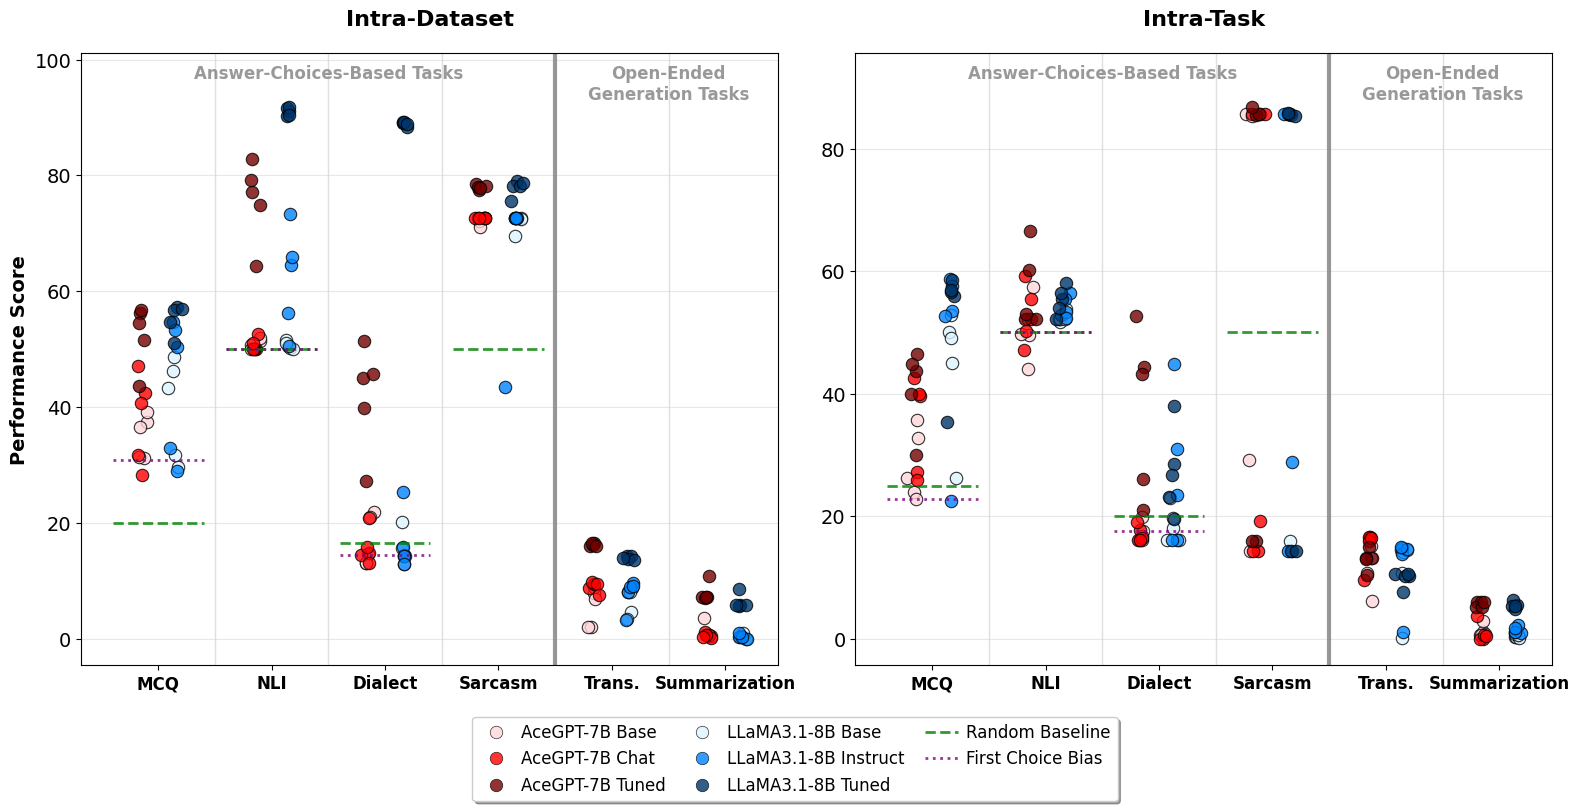

In [6]:
plot = create_scatter_plot()
plt.savefig('Notebooks/results_visualization/scatter_plot.pdf', dpi=300, bbox_inches='tight',format='pdf')
plt.show()